In [1]:
import pandas as pd
import numpy as np
#the table is in the file housing.csv
housing = pd.read_csv("housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# type of variable 'housing' is pandas DataFrame
type(housing)

pandas.DataFrame

In [3]:
# get the general information of the DataFrame
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
print(housing.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

In [5]:
#check to see if there is nan in the table
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# get one column of the DataFrame
housing['ocean_proximity']

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: str

In [7]:
# get two columns of the DataFrame
table1=housing[['longitude', 'latitude']]
table1.head()

,longitude,latitude
0,-122.23,37.88
1,-122.22,37.86
2,-122.24,37.85
3,-122.25,37.85
4,-122.25,37.85


In [8]:
type(table1)

pandas.DataFrame

In [9]:
# functions in sk-learn may not work well with DataFrame
table1=table1.values
type(table1)

numpy.ndarray

In [10]:
# it is a 2D array
table1.shape

(20640, 2)

In [11]:
# get an element at row-i and column-j of table1
i=1; j=0
table1[i,j]

np.float64(-122.22)

In [12]:
# get row-0 from table1
table1[0,:]

array([-122.23,   37.88])

In [13]:
# get column-0 from table1
table1[:,0]

array([-122.23, -122.22, -122.24, ..., -121.22, -121.32, -121.24],
      shape=(20640,))

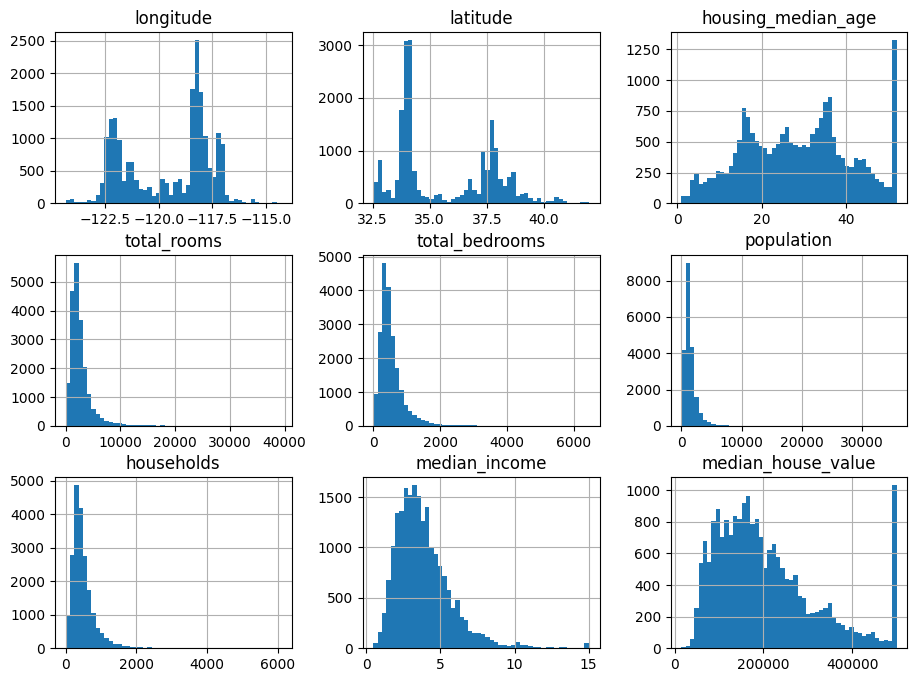

In [14]:
# show the histograms: one histogram corresponds to one column
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(11,8))
plt.show()

<Axes: >

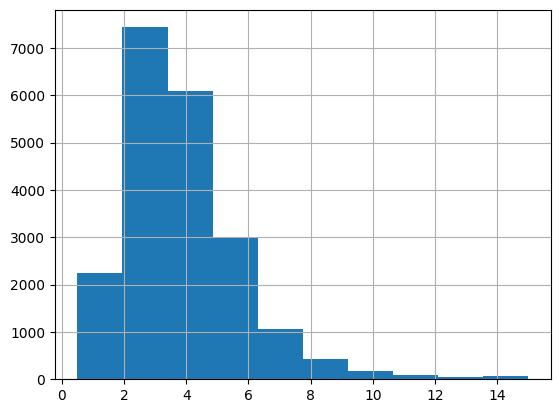

In [15]:
#show the histogram of a column
housing["median_income"].hist()

### visualize the data points using a pandas built-in function: plot

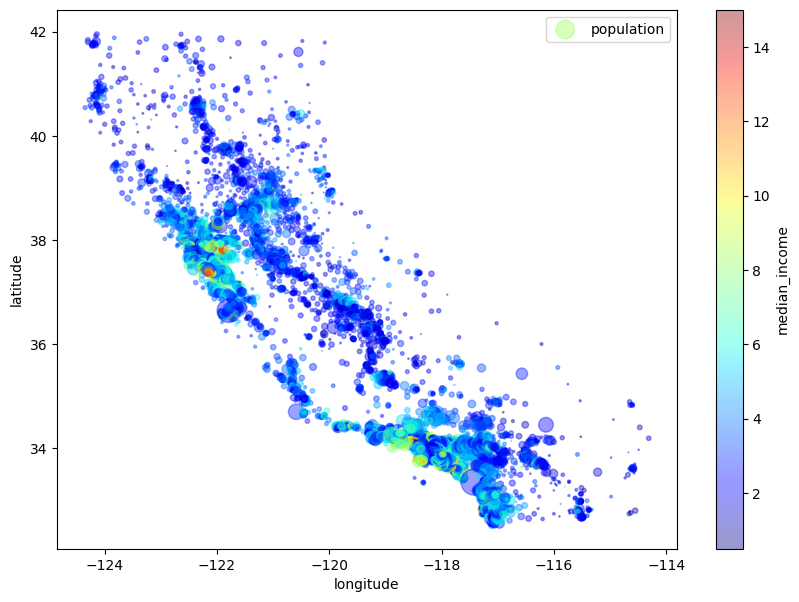

In [16]:
#each dot represents an area
#the color of a dot shows the median_income in that area
#the size of a dot shows the population in that area
housing.plot(kind="scatter", x="longitude", y="latitude",
    s=housing['population']/100, 
    label="population",
    c="median_income", cmap=plt.get_cmap("jet"),
    colorbar=True, alpha=0.4, figsize=(10,7),
)
plt.legend()

### visualize the data points on the map of california using matplotlib

Text(0.5, 0, 'Longitude')

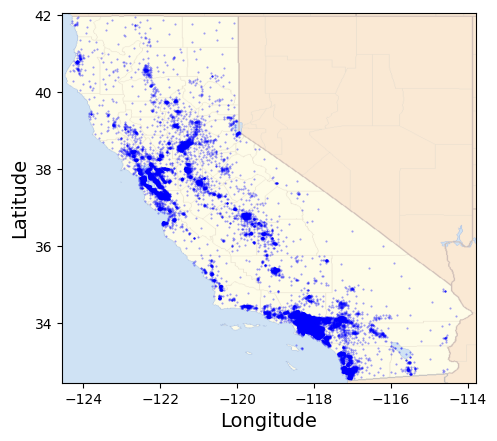

In [17]:
# the map is an image,'california.png'
from skimage.io import imread
#load the map
california_img=imread('california.png')
#show the map
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)
#show the data points
plt.scatter(x=housing['longitude'], y=housing['latitude'], 
            color='b',  marker='.', s=1, alpha=0.4)
#add labels 
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

In [18]:
# do not modify this cell
housing=pd.get_dummies(housing)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


cluster

In [19]:
#get a new table by selecting columns related to location

data1 = housing[['longitude', 'latitude','ocean_proximity_<1H OCEAN','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']].copy()

#data1 head()
dummy_cols = [c for c in data1.columns if 'ocean_proximity' in c]
data1[dummy_cols] = data1[dummy_cols].astype(int)
data1.head()



,longitude,latitude,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,0,0,0,1,0
1,-122.22,37.86,0,0,0,1,0
2,-122.24,37.85,0,0,0,1,0
3,-122.25,37.85,0,0,0,1,0
4,-122.25,37.85,0,0,0,1,0


In [20]:
#type of data1 is DataFrame

data1=data1.to_numpy()
type(data1)

numpy.ndarray

In [21]:
#normalize data1 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data1n = scaler.fit_transform(data1)

In [22]:
data1n.shape

(20640, 7)

In [23]:
#run k-means on data1n

from sklearn.cluster import KMeans
# clustering 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
label1 = kmeans.fit_predict(data1n)

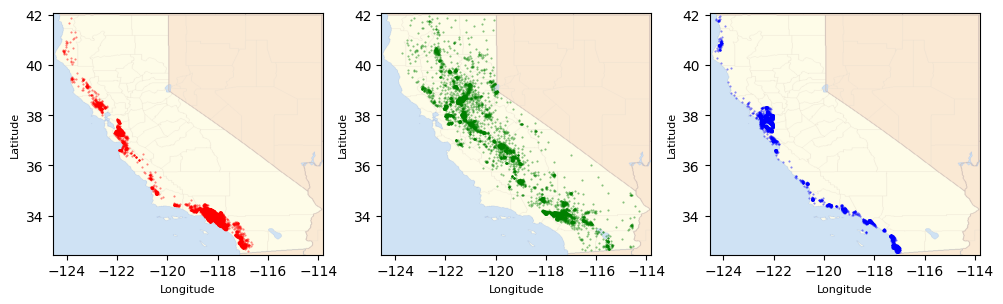

In [24]:
#show the clusters using different colors

color = ['r', 'g', 'b', 'm', 'c', 'y']

fig, ax = plt.subplots(1, 3, figsize=(10, 6))

for k in range(0, 3):
    ax[k].imshow(california_img,
                 extent=[-124.55, -113.80, 32.45, 42.05],
                 alpha=0.5)
    
    ax[k].scatter(x=data1[label1 == k, 0],
                  y=data1[label1 == k, 1],
                  color=color[k],
                  marker='.',
                  s=1,
                  alpha=0.5)
    
    ax[k].set_xlabel("Longitude", fontsize=8)
    ax[k].set_ylabel("Latitude", fontsize=8)

plt.tight_layout()
plt.show()


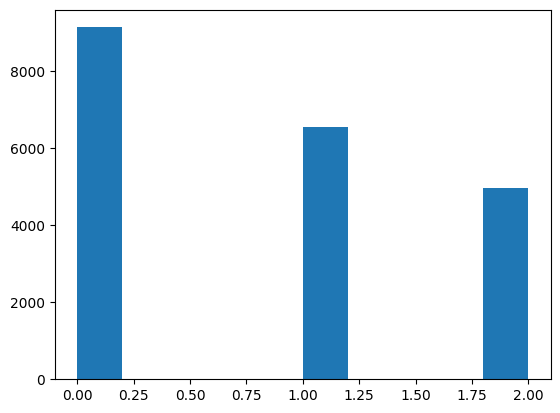

In [25]:
#plot the histogram of cluster labels in label1
plt.hist(label1)
plt.show()

## 2. cluster data to find out where high/low income people live


In [26]:
#select some columns from housing

data2= housing[['longitude', 'latitude','median_income']].copy()
data2

,longitude,latitude,median_income
0,-122.23,37.88,8.3252
1,-122.22,37.86,8.3014
2,-122.24,37.85,7.2574
3,-122.25,37.85,5.6431
4,-122.25,37.85,3.8462
...,...,...,...
20635,-121.09,39.48,1.5603
20636,-121.21,39.49,2.5568
20637,-121.22,39.43,1.7000
20638,-121.32,39.43,1.8672


In [27]:
#type

data2=data2.to_numpy()

In [28]:
#normalize data2 using MinMaxScaler

scaler = MinMaxScaler()
data2n = scaler.fit_transform(data2)

In [29]:
#run k-means on data2n to get cluster labels

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
label2 = kmeans.fit_predict(data2n)

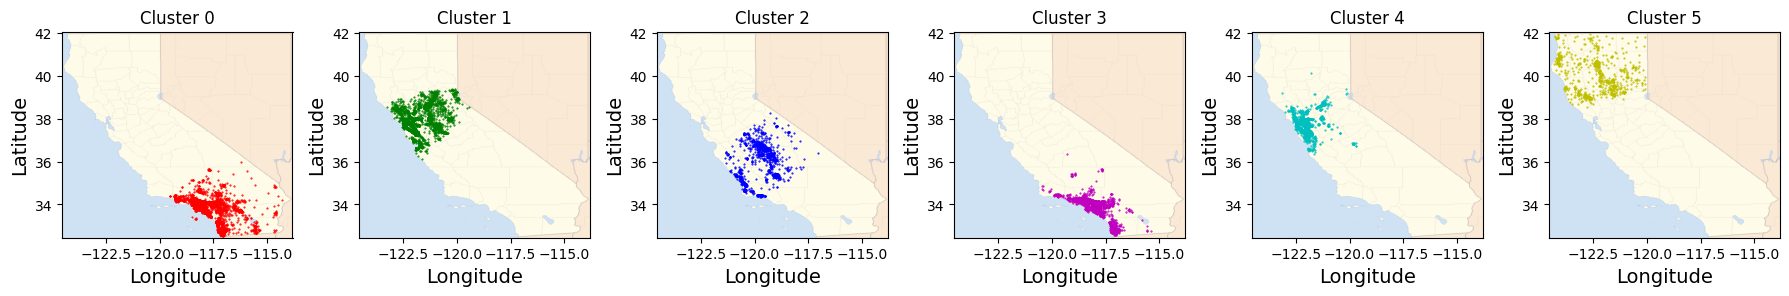

In [30]:
#show the clusters using different colors

color = ['r', 'g', 'b', 'm', 'c', 'y']

fig, ax = plt.subplots(1,6, figsize=(18, 4))   
ax = ax.ravel()

for k in range(0, 6):
    ax[k].imshow(california_img,
                 extent=[-124.55, -113.80, 32.45, 42.05],
                 alpha=0.5)

    ax[k].scatter(x=data2[label2 == k, 0],   # longitude
                  y=data2[label2 == k, 1],   # latitude
                  color=color[k],
                  marker='.',
                  s=1,
                  alpha=1)

    ax[k].set_xlabel("Longitude", fontsize=14)
    ax[k].set_ylabel("Latitude", fontsize=14)
    ax[k].set_title(f"Cluster {k}", fontsize=12)

plt.tight_layout()
plt.show()

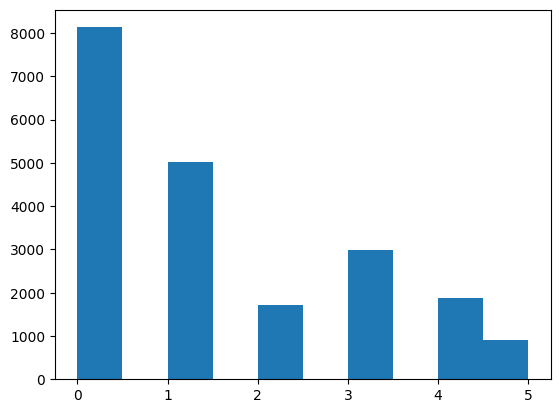

In [31]:
#plot the histogram of cluster labels

plt.hist(label2)
plt.show()

In [32]:
# compute the average value of 'median_income' in each cluster
# print out the average values

mhv = housing['median_income'].values

for k in np.unique(label2):
    mhv_k = mhv[label2 == k]
    mhv_k_mean = mhv_k.mean()
    print(mhv_k_mean)

3.097477329727071
3.2226293567018525
2.7824420467836255
6.47873675041876
6.497118832891246
2.3987544751381216


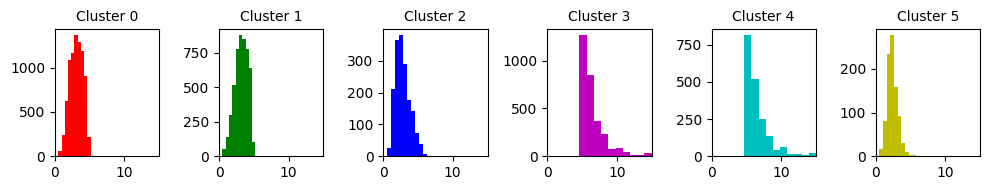

In [33]:
# show the histograms of 'median_income' in each cluster

color = ['r', 'g', 'b', 'm', 'c', 'y']

fig, ax = plt.subplots(1, 6, figsize=(10, 2))

for k in range(0, 6):
    ax[k].hist(x=data2[label2 == k, 2],
               color=color[k],
               bins=10)
    ax[k].set_xlim(0, 15)
    ax[k].set_title(f"Cluster {k}", fontsize=10)

plt.tight_layout()
plt.show()

we can clearly see some clusters of high-income people

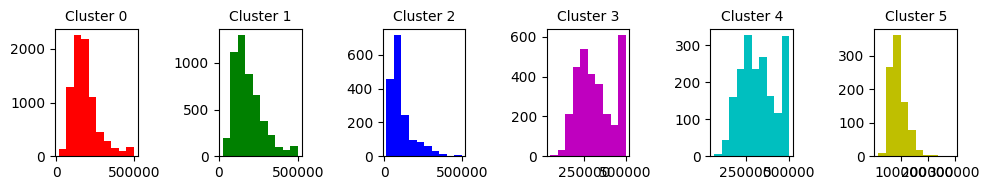

In [34]:
# show the histogram of 'median_house_value' in each cluster

color = ['r', 'g', 'b', 'm', 'c', 'y']

mhv = housing['median_house_value'].values

fig, ax = plt.subplots(1,6, figsize=(10, 2))

for k in range(0, 6):
    ax[k].hist(x=mhv[label2 == k],
               color=color[k],
               bins=10)
    ax[k].set_title(f"Cluster {k}", fontsize=10)

plt.tight_layout()
plt.show()

Some people have low income but live in very expensive houses